In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from exact import exact_solution_dirichlet
from fem import solve_poisson_1d
from pinn import PINN

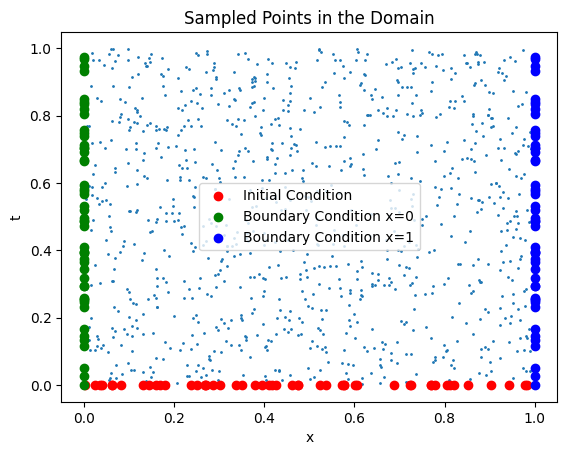

In [7]:
# 2d point generation for PINNs
import random
import numpy as np
import matplotlib.pyplot as plt

n_points = 1000
bound_x = (0, 1)
bound_t = (0, 1)


x_points = np.random.uniform(bound_x[0], bound_x[1], n_points)
t_points = np.random.uniform(bound_t[0], bound_t[1], n_points)
# add initial and boundary points
n_ib_points = 50
ic = np.random.uniform(bound_x[0], bound_x[1], n_ib_points)
bc = np.random.uniform(bound_t[0], bound_t[1], n_ib_points)

t_0 = np.zeros(n_ib_points)  # t=0
t_1 = np.ones(n_ib_points)   # t=1
x_0 = np.zeros(n_ib_points)  # x=0
x_1 = np.ones(n_ib_points)   # x=1   

initial_points = np.vstack((ic, t_0)).T
boundary_points_left = np.vstack((x_0, bc)).T
boundary_points_right = np.vstack((x_1, bc)).T

points = np.vstack((x_points, t_points)).T

# plot the sampled points
plt.scatter(x_points, t_points, s=1)
plt.scatter(initial_points[:,0], initial_points[:,1], color='red', label='Initial Condition')
plt.scatter(boundary_points_left[:,0], boundary_points_left[:,1], color='green', label='Boundary Condition x=0')
plt.scatter(boundary_points_right[:,0], boundary_points_right[:,1], color='blue', label='Boundary Condition x=1')
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.title('Sampled Points in the Domain')
# plt.tight_layout()
plt.show()

In [4]:

# Ejemplo B: f(x)=sin(pi x), Dirichlet no homogéneo
f_numpy = lambda x: np.sin(np.pi*x)
f_torch = lambda x: torch.sin(torch.pi*x)
L  = 4.0
g0 = 0.0
gL = -0.5

x_true = np.linspace(0, L, 1000)
u_exact = exact_solution_dirichlet(f_numpy, x_true, L=L, g0=g0, gL=gL, M=400)


## FEM

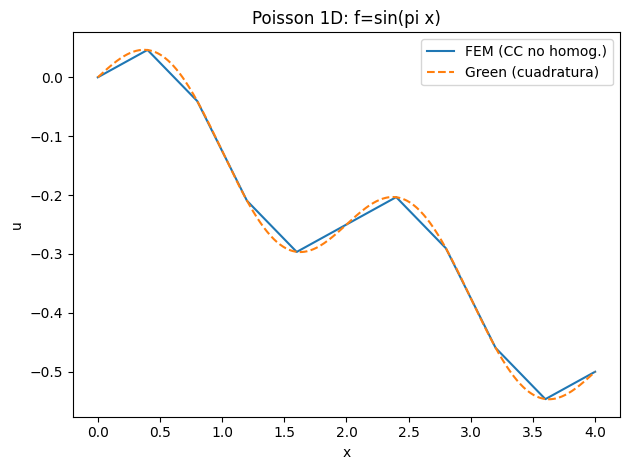

In [5]:

x, u_fem = solve_poisson_1d(f_numpy, L=L, N=10, g0=g0, gL=gL)


# Comparación con la solución cerrada cuando CC son homogéneas:
# si g0=gL=0, entonces u_ex(x)=∫ G(x,s) sin(pi s) ds = sin(pi x)/pi^2
# (la integral reproduce esa fórmula; con CC no homogéneas, se suma la parte afín)

plt.figure()

plt.plot(x, u_fem, label="FEM (CC no homog.)")
plt.plot(x_true, u_exact, "--", label="Green (cuadratura)")
plt.xlabel("x"); plt.ylabel("u")
plt.title("Poisson 1D: f=sin(pi x)")
plt.legend(); plt.tight_layout()

plt.show()


## PINN

Epoch 500, Loss: 0.002086
Epoch 1000, Loss: 0.000243
Epoch 1500, Loss: 0.000103
Epoch 2000, Loss: 0.001823
Training time for PINN: 3.7158 seconds


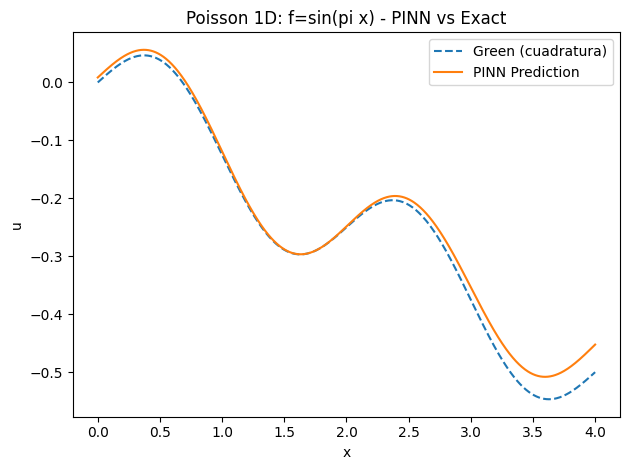

In [ ]:
# ---------------- Data Loading ----------------------
x_true = np.linspace(0, L, 1000)

x_true_tensor = torch.tensor(x_true, dtype=torch.float32).unsqueeze(-1)
u2_ex_tensor = torch.tensor(u_exact, dtype=torch.float32).unsqueeze(-1)
X_train = torch.cat([x_true_tensor], dim=1)
x_ic = torch.tensor([0, L], dtype=torch.float32).unsqueeze(-1)

train_data = [X_train, x_ic]
boundary_conditions = torch.tensor([g0, gL], dtype=torch.float32)

# ---------------- Training --------------------------
layers = [1, 10, 10, 1]
lr = 1e-2
epochs = 2000
print_every = 500
weight_factors = [1, 1]  # [equation, initial condition, boundary conditions]
pinn = PINN(layers, lr)

t0_pinn = time.time()
pinn.train(
    epochs,
    print_every,
    train_data,
    weight_factors,
    boundary_conditions,
    f_torch,
    x_ic,
)
t1_pinn = time.time()
print(f"Training time for PINN: {t1_pinn - t0_pinn:.4f} seconds")
u_pinn = pinn.predict(X_train)
plt.figure()
plt.plot(x_true, u_exact, "--", label="Green (cuadratura)")
plt.plot(x_true, u_pinn, label="PINN Prediction")
plt.xlabel("x"); plt.ylabel("u")
plt.title("Poisson 1D: f=sin(pi x) - PINN vs Exact")
plt.legend(); plt.tight_layout()
plt.show()

# Losses comparative
